In [2]:
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.tools.simple import Tool
from langgraph.graph import START, END, StateGraph, MessagesState
from langchain_groq import ChatGroq
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun #requires this for arxiv query run tool
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper
from typing_extensions import TypedDict
#REDUCERS
from typing import Annotated
from langgraph.graph.message import add_messages

C:\Users\ybalasaraswa\AppData\Roaming\Python\Python314\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
C:\Users\ybalasaraswa\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
wiki_api_wrapper = WikipediaAPIWrapper(top_k_results=10, doc_content_chars_max=500)
arxiv_api_wrapper = ArxivAPIWrapper(top_k_results=10, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=wiki_api_wrapper)
arxiv = ArxivQueryRun(api_wrapper=arxiv_api_wrapper)
load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")
langchain_api_key = os.getenv("LANGCHAIN_API_KEY")
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_PROJECT'] = "ReAct_agent"
llm = ChatGroq(
    api_key=groq_api_key,
    model="openai/gpt-oss-120b"
)

In [4]:
# arxiv.invoke("is there any research papers published by openText?") #testing Arxiv tool
# wiki.invoke("who is bramhanandham") #testing wikipedia tool -> this is giving irrelevant results

In [5]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()
# tavily.invoke("provide me the latest news about openText business networks") #testing Tavily Search tool

C:\Users\ybalasaraswa\AppData\Local\Temp\ipykernel_3724\979446887.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [6]:
def add(a: int, b: int) -> int:
    """
    add two numbers a and b, and return the result
    Args:
        a (int): first number
        b (int): second number
    """
    return a + b

def multiply(a: int, b: int) -> int:
    """
    multiply two numbers a and b, and return the result
    Args:
        a (int): first number
        b (int): second number
    """
    return a * b

def divide(a: int, b: int) -> float:
    """
    divide two numbers a and b, and return the result
    Args:
        a (int): first number
        b (int): second number
    """
    if b == 0:
        raise ValueError("Cannot divide by zero")
    return a / b

 #adding some basic math tools to our tool list

tools = [arxiv, wiki, tavily, add, multiply, divide]

In [7]:
#binding out tools with the LLM
llm_with_tools = llm.bind_tools(tools=tools)

In [8]:

llm_with_tools.invoke([
    HumanMessage(content="provide me the latest news about openText business networks")
])


AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants latest news about OpenText Business Networks. Need current events. Use search tool tavily_search_results_json.', 'tool_calls': [{'id': 'fc_0317a6e2-f734-4b15-8583-1e036639d969', 'function': {'arguments': '{"query":"latest news OpenText Business Networks 2024"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 445, 'total_tokens': 509, 'completion_time': 0.155597981, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.027566686, 'prompt_tokens_details': None, 'queue_time': 0.201421403, 'total_time': 0.183164667}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cfbfd-b0e5-7451-9d48-a09e688561f4-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': 

### Building a ChatBot with multiple tools using LangGraph

In [9]:
class State(TypedDict):
    """
    Messages have the type ""List"" the add_messages function
     in the annotations defines how the state key should be updated
     in this case it updates messages to the list rather than overriding them
    """
    messages: Annotated[list[MessagesState], add_messages]

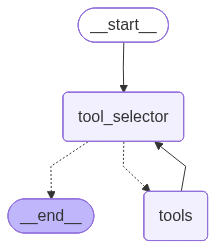

In [14]:
from IPython.display import Image, display
from langgraph.prebuilt import ToolNode, tools_condition

#Node definition
def tool_selector(state: State):
    return {
        "messages": llm_with_tools.invoke(state['messages'])
    }

# Builder graph
builder = StateGraph(MessagesState)
builder.add_node("tool_selector", tool_selector)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START,"tool_selector")
builder.add_conditional_edges("tool_selector", tools_condition)
builder.add_edge("tools", "tool_selector") # this is what defining the ReAct agent
# builder.add_edge("tools",END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
messages = graph.invoke({"messages": HumanMessage("what is the latest research on openText business network? and add 5 plus 5 and then multiply 2 * 3 and devide 10 by 2")}) #tavily Tool call
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

what is the latest research on openText business network? and add 5 plus 5 and then multiply 2 * 3 and devide 10 by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_9107b800-b5b1-4c9f-b3ad-e9cfecb0e47a)
 Call ID: fc_9107b800-b5b1-4c9f-b3ad-e9cfecb0e47a
  Args:
    query: OpenText Business Network latest research
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Latest OpenText Business Network Cloud Innovations Drive ...", "url": "https://s23.q4cdn.com/197378439/files/doc_news/Latest-OpenText-Business-Network-Cloud-Innovations-Drive-Seamless-Connectivity-Across-Digital-Ecosystems-2022.pdf", "content": "Latest OpenText Business Network Cloud Innovations Drive Seamless Connectivity Across Digital Ecosystems 6/6/2022 OpenText Showcases Business-to-Anythin

In [12]:
messages = graph.invoke({"messages": HumanMessage("what are the latest research papers about Quantum computing?")}) #Arxiv tool call
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

what are the latest research papers about Quantum computing?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_9013ee76-36d6-4387-a5d9-37468889d085)
 Call ID: fc_9013ee76-36d6-4387-a5d9-37468889d085
  Args:
    query: latest quantum computing research papers 2024
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Unwrap the Top 10 Quantum Research Stories of 2024", "url": "https://thequantuminsider.com/2024/12/25/its-starting-to-look-a-lot-like-quantum-unwrap-the-top-10-quantum-research-stories-of-2024/", "content": "## Quantinuum Unveils First Contribution Toward Responsible AI — Uniting Power of Its Quantum Processors With Experimental Work on Integrating Classical, Quantum Computing\n\nQuantinuum implemented a scalable Quantum Natural Language Processin

In [13]:
messages = graph.invoke({"messages": HumanMessage("what is Operation Epic Fury? ")}) #tavily Tool call
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

what is Operation Epic Fury? 
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_d11c2b2e-14d6-4a1c-a4d2-519a5dfb917a)
 Call ID: fc_d11c2b2e-14d6-4a1c-a4d2-519a5dfb917a
  Args:
    query: Operation Epic Fury
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Operation Epic Fury and the Remnants of Iran's Nuclear Program", "url": "https://www.csis.org/analysis/operation-epic-fury-and-remnants-irans-nuclear-program", "content": "#### Conclusion\n\nOperations Epic Fury and Roaring Lion are likely the start of a prolonged conflict with Iran. The U.S.-Israel coalition has moved beyond proliferation targets and is seeking to destroy the Iranian government entirely. This conflict has already spread across the Middle East, involving strikes in more than half a doze